# Iris Species Classification

The data file reports four measurements taken on Iris flowers, along with the species each flower belongs to. The goal is to predict the species from these measurements. This is a supervised, multiclass classification problem, since the species is known for every flower and three different species are possible. The analysis follows a progressive approach, from exploring the data to comparing several models and predicting on a new observation.

## 1. Imports

This consists of importing the packages needed for the whole program, from data handling to model training and evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")
pd.set_option("display.precision", 2)
np.random.seed(42)

## 2. Loading the data

Loading the data file makes it possible to explore it and prepare the rest of the analysis.

In [2]:
data = pd.read_csv("Iris.csv")
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


**Interpretation :** Each row corresponds to one flower, described by its sepal length, sepal width, petal length and petal width, all expressed in centimetres, together with its species. An `Id` column is also present but carries no information about the flower itself, so it will need to be dropped before modelling.

## 3. First look at the dataset

A first review checks the size of the file, the column types and the amount of missing values, before going further in the analysis.

In [3]:
data = data.drop(columns=["Id"])

X = data.drop(columns=["Species"])
y = data["Species"]
species_names = sorted(y.unique())

print("Total number of observations:", data.shape[0])
print("Number of explanatory variables:", X.shape[1])
print("Number of classes to predict:", len(species_names))
print("Classes:", species_names)
print()
data.info()

Total number of observations: 150
Number of explanatory variables: 4
Number of classes to predict: 3
Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


**Interpretation :** The `Id` column has been removed since it is just a row index. The file contains 150 observations and 4 explanatory variables, all stored as `float64`, for 3 possible classes: `Iris-setosa`, `Iris-versicolor` and `Iris-virginica`.

In [4]:
data.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

**Interpretation :** There is no missing value anywhere in the dataset, and the four variables are already continuous and numeric. So there is no need for imputation or encoding, and the analysis can move directly to exploring the distributions.

## 4. Descriptive statistics

These statistics give a first idea of the distribution of each variable, through the mean, the spread and the extreme values.

In [5]:
X.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


**Interpretation :** The variables are not at all on the same scale: petal length ranges from 1 to 6.9 cm while sepal width stays within a much narrower 2 to 4.4 cm band, and petal width goes from just 0.1 to 2.5 cm. This matters for models based on distances or margins, notably logistic regression, the support vector machine and k-nearest neighbors, which could otherwise give more weight to variables simply because their numeric values are larger. The data will therefore be standardized before training these models.

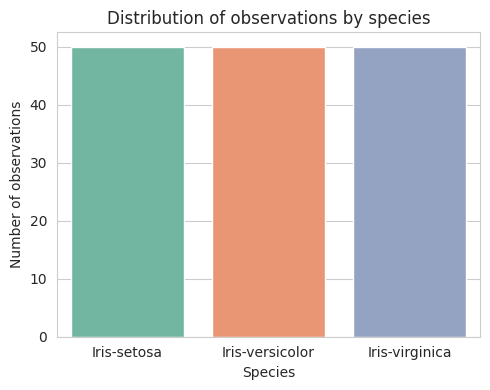

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [6]:
counts = y.value_counts().reindex(species_names)

plt.figure(figsize=(5, 4))
sns.countplot(x=data["Species"], order=species_names, hue=data["Species"], palette="Set2", legend=False)
plt.title("Distribution of observations by species")
plt.xlabel("Species")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()

counts

**Interpretation :** There are exactly 50 observations per species, so the dataset is perfectly balanced. This is convenient, since there is no need to worry about a class imbalance that would distort accuracy as an evaluation metric later on.

## 5. Statistics by species

The same statistics are recalculated by grouping the flowers by species, in order to spot the variables that distinguish them best.

In [7]:
data.groupby("Species")[X.columns].mean().reindex(species_names)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,5.01,3.42,1.46,0.24
Iris-versicolor,5.94,2.77,4.26,1.33
Iris-virginica,6.59,2.97,5.55,2.03


**Interpretation :** Petal length and petal width differ sharply between species: petal length averages 1.46 cm for setosa against 4.26 cm for versicolor and 5.55 cm for virginica, and petal width follows the same widening pattern, from 0.24 to 1.33 to 2.03 cm. Sepal width, on the other hand, stays close across the three species, from 2.77 to 3.42 cm, so it looks like the least useful variable for telling species apart, while sepal length falls in between.

## 6. Correlations

The correlations between variables are measured here, in order to spot those that carry redundant information.

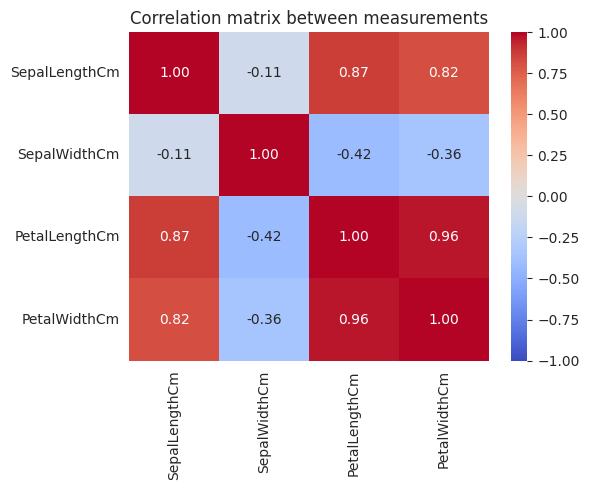

In [8]:
correlation_matrix = X.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation matrix between measurements")
plt.tight_layout()
plt.show()

**Interpretation :** Petal length and petal width are extremely strongly correlated (0.96), which makes sense since a bigger flower tends to have all its dimensions larger together, and both are also strongly correlated with sepal length (0.87 and 0.82). Sepal width stands apart, with weak, slightly negative correlations to the other three variables, confirming it carries more independent, and less discriminative, information.

## 7. Visualizing separability

A cross visualization of the variables by species makes it easier to judge how separable the classes are than plain numbers would.

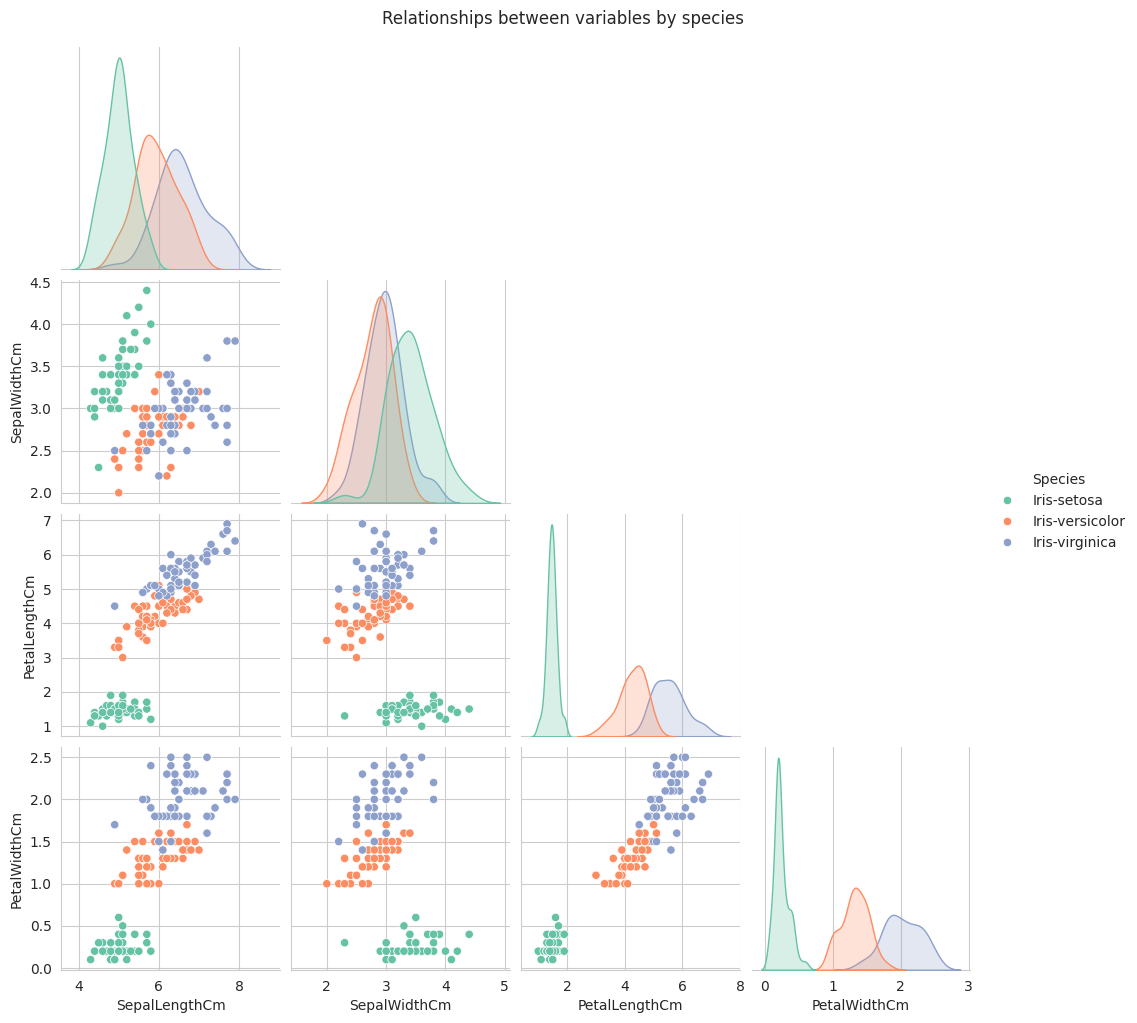

In [9]:
pairplot = sns.pairplot(data, hue="Species", hue_order=species_names, corner=True, palette="Set2")
pairplot.fig.suptitle("Relationships between variables by species", y=1.02)
plt.show()

**Interpretation :** This confirms what the statistics already suggested. Setosa forms a cleanly isolated cluster on almost every pair of variables, especially the petal measurements, so it should be easy to separate from the other two. Versicolor and virginica overlap more, particularly on sepal length and sepal width, so any classification errors should mostly occur between these two species.

## 8. Splitting into training and test data

The data is split into two parts, one to train the models and another set aside to evaluate them on data they have never seen. The split is stratified by species so that the 50/50/50 balance is preserved in both sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
y_test.value_counts().reindex(species_names)

Training set size: 120
Test set size: 30


Species
Iris-setosa        10
Iris-versicolor    10
Iris-virginica     10
Name: count, dtype: int64

**Interpretation :** The 150 flowers are split into 120 for training and 30 for testing, with the stratification keeping exactly 10 flowers of each species in the test set. This guarantees that the evaluation covers all three classes equally, rather than being skewed toward whichever species happened to be drawn more often.

## 9. Standardization

All variables are brought here to a comparable scale, so that none dominates simply because its values are larger, which matters for the distance- and margin-based models trained next.

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pd.DataFrame(X_train_scaled, columns=X.columns).describe().loc[["mean", "std"]]

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
mean,-1.37e-16,4.55e-16,-9.07e-17,5.37e-17
std,1.00e+00,1.00e+00,1.00e+00,1.00e+00


**Interpretation :** The scaler is fitted on the training set only, to avoid leaking any information from the test set, and then applied to both. After scaling, every training variable has a mean of 0 and a standard deviation of 1, so petal length no longer weighs more than sepal width simply because it was originally measured on a wider numeric range.

## 10. Training the models

Several different classification models are trained here, in order to compare their performance rather than relying on a single arbitrary choice.

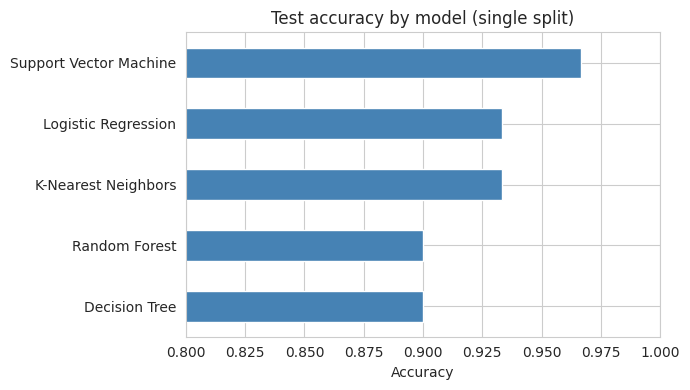

Support Vector Machine    0.97
Logistic Regression       0.93
K-Nearest Neighbors       0.93
Random Forest             0.90
Decision Tree             0.90
Name: Test accuracy, dtype: float64

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
}

test_accuracies = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    test_accuracies[name] = accuracy_score(y_test, predictions)

accuracy_table = pd.Series(test_accuracies, name="Test accuracy").sort_values(ascending=False)

plt.figure(figsize=(7, 4))
accuracy_table.plot(kind="barh", color="steelblue")
plt.title("Test accuracy by model (single split)")
plt.xlabel("Accuracy")
plt.xlim(0.8, 1.0)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

accuracy_table

**Interpretation :** On this single split, the support vector machine reaches the highest accuracy at 0.97, ahead of logistic regression and k-nearest neighbors, both at 0.93, while the decision tree and the random forest trail slightly at 0.90. These figures depend on which 30 flowers happened to land in the test set, though, so they should be confirmed with a more robust method before picking a final model.

## 11. Cross validation

The models are re-evaluated here with 5-fold cross validation, a more reliable method than a single split, in order to confirm or correct the ranking obtained previously.

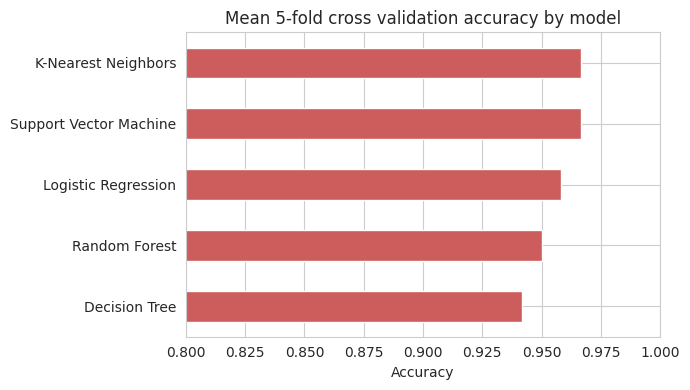

K-Nearest Neighbors       0.97
Support Vector Machine    0.97
Logistic Regression       0.96
Random Forest             0.95
Decision Tree             0.94
Name: Mean cross validation accuracy, dtype: float64

In [13]:
cross_val_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    cross_val_results[name] = scores.mean()

cross_val_table = pd.Series(cross_val_results, name="Mean cross validation accuracy").sort_values(ascending=False)

plt.figure(figsize=(7, 4))
cross_val_table.plot(kind="barh", color="indianred")
plt.title("Mean 5-fold cross validation accuracy by model")
plt.xlabel("Accuracy")
plt.xlim(0.8, 1.0)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

cross_val_table

**Interpretation :** Cross validation narrows the gap seen on the single split: k-nearest neighbors and the support vector machine come out on top, both averaging 0.97 accuracy across the 5 folds, ahead of logistic regression at 0.96, and the random forest and decision tree at 0.95 and 0.94. The single split had favoured the support vector machine somewhat more clearly, so cross validation is what should be trusted to pick the final model, since it averages performance over several different splits instead of relying on just one.

In [14]:
best_model_name = cross_val_table.index[0]
best_model = models[best_model_name]

print("Selected model:", best_model_name)
print("Mean cross validation accuracy:", round(cross_val_table.iloc[0], 4))

Selected model: K-Nearest Neighbors
Mean cross validation accuracy: 0.9667


**Interpretation :** The k-nearest neighbors model is selected, since it obtains the best mean cross validation accuracy, essentially tied with the support vector machine. It is retrained on the full scaled training set to be evaluated in detail on the untouched test set.

## 12. Detailed look at the best model

The performance of the best model is broken down here by species, since a good overall accuracy can mask weaknesses on a particular class.

In [15]:
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

report = classification_report(y_test, y_pred, target_names=species_names)
print(report)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



**Interpretation :** Setosa is identified perfectly, with a precision and a recall of 1.00. Virginica is predicted with perfect precision (1.00) but a lower recall of 0.80, meaning that a few virginica flowers get misclassified as something else, while versicolor shows the opposite pattern, with a perfect recall of 1.00 but a lower precision of 0.83, meaning it absorbs those misclassified virginica flowers. Overall accuracy on the test set is 0.93, close to the 0.97 obtained in cross validation, which confirms the model generalises well.

## 13. Confusion matrix

The confusion matrix shows precisely which species are confused with each other, something the previous metrics could not show directly.

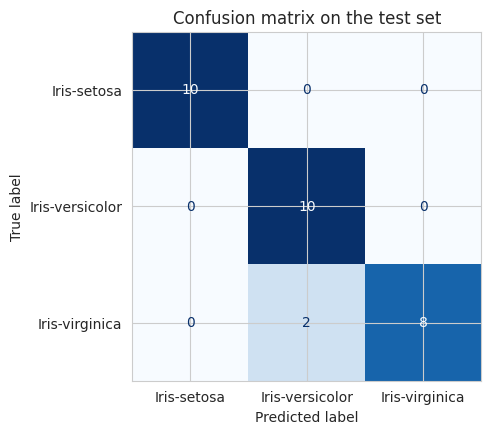

In [16]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=species_names)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.title("Confusion matrix on the test set")
plt.tight_layout()
plt.show()

**Interpretation :** All 10 setosa and all 10 versicolor flowers of the test set are classified correctly. The only errors are 2 virginica flowers wrongly predicted as versicolor, out of 10, which matches exactly the overlap observed earlier in the pairplot between these two species. Setosa, being visually and numerically distinct, produces no errors at all.

## 14. Feature importance

The goal here is to understand which variables weigh most in a model's decisions, when the model type allows for it directly.

K-Nearest Neighbors does not expose a direct feature importance score.
A random forest is trained separately below, purely to illustrate which variables matter most.


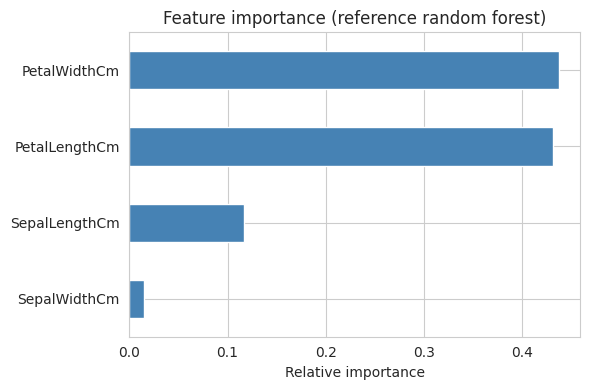

In [17]:
tree_based_models = ["Decision Tree", "Random Forest"]

if best_model_name in tree_based_models:
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)

    plt.figure(figsize=(6, 4))
    importances.plot(kind="barh", color="steelblue")
    plt.title("Feature importance in the model's decisions")
    plt.xlabel("Relative importance")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not expose a direct feature importance score.")
    print("A random forest is trained separately below, purely to illustrate which variables matter most.")

    reference_forest = RandomForestClassifier(random_state=42)
    reference_forest.fit(X_train_scaled, y_train)
    importances = pd.Series(reference_forest.feature_importances_, index=X.columns).sort_values(ascending=True)

    plt.figure(figsize=(6, 4))
    importances.plot(kind="barh", color="steelblue")
    plt.title("Feature importance (reference random forest)")
    plt.xlabel("Relative importance")
    plt.tight_layout()
    plt.show()

**Interpretation :** K-nearest neighbors has no built-in notion of feature importance, since it classifies a flower simply by looking at its closest neighbors in the scaled feature space, rather than by weighting variables explicitly. A random forest trained on the same data for reference purposes confirms the pattern already seen in the correlation and grouped statistics: petal length and petal width dominate the decision, while sepal width contributes only marginally, and sepal length sits in between.

## 15. Prediction on a new flower

The trained model is applied here to a new observation, in order to check its use in real conditions.

In [18]:
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=X.columns,
)

new_flower_scaled = scaler.transform(new_flower)
prediction = best_model.predict(new_flower_scaled)[0]

print("Measurements provided:", new_flower.values.tolist()[0])
print("Predicted species:", prediction)

Measurements provided: [5.1, 3.5, 1.4, 0.2]
Predicted species: Iris-setosa


**Interpretation :** For a flower with a 5.1 cm sepal length, 3.5 cm sepal width, 1.4 cm petal length and 0.2 cm petal width, the model predicts `Iris-setosa`. This is consistent with the training data, since these small petal measurements sit squarely within the range observed for setosa flowers, whose petal length rarely exceeds about 2 cm, well below the shortest versicolor or virginica petals.

## Conclusion

The exploratory analysis showed early on that petal length and petal width are the variables that really separate the three species, while sepal width contributes comparatively little information, a pattern confirmed later both by the correlation matrix and by the reference feature importance plot.

After training and comparing five models, cross validation selected k-nearest neighbors, essentially tied with the support vector machine, as the most reliable classifier, ahead of logistic regression, the random forest and the decision tree. On the held-out test set it reaches 93% accuracy, correctly identifying every setosa and versicolor flower, with its only errors being 2 virginica flowers confused with versicolor, exactly where the pairplot had already suggested the two species overlap. This makes the model reliable enough for practical use, as illustrated by the correct prediction obtained on a new, unseen flower.